<table border=0 width="100%"><tr><td><p align="left"><img src="..\img\logo-1.jpg" align="left" width=300></p></td><td><font size=3><B>preprocess data using pandas - 1 (Jun Wang)</B></font></td></tr></table>

# 1. Content
* introduction to the case
* series and dataframe
* process data using pandas
* process text data using pandas

# 2. Introduction to the case（课程论文）

* 了解INVEST投资部的任务，理解社交媒体数据与搜索引擎指数对股市预测的价值；
* 认识我们的工作步骤

## 2.1 The task of investment department of INVEST
中国是巨大的影视市场，INVEST拟投资中国传媒娱乐领域，光线传媒是其潜在的投资对象。光线传媒（ENLIGHT MEDIA）成立于1998年，主营业务包括电视节目制作与发行，电影投资、制作等。

大家记得看过光线传媒投资的电影吗？《我和我的祖国》、《哪吒之魔童降世》、《泰囧》、《冲出地球》、《深海》、《大圣归来》？

https://baijiahao.baidu.com/s?id=1742096894801372860&wfr=spider&for=pc

大家都是INVEST公司投资部的研究人员，该如何预测[该公司](http://quote.eastmoney.com/sz300251.html?from=BaiduAladdin)股价的涨跌呢？


## 2.2 Social media, search trend and stock market forecasts
社交媒体上数据可以体现投资人对企业或大盘的情感，搜索引擎指数体现投资人的注意力。这两类数据的特点：
* 社交媒体数据可以用于预测股市的涨跌、交易量等。社交媒体数据虽然可能有偏差（例如水军），但是会影响个人投资者的决策；搜索数据更隐蔽一般没有作弊，二者可以互补。
* 搜索数据代表投资人的注意力。当个人投资者在购买时，他们必须从大量的选择中进行选择。然而，当他们出售时，他们只能出售他们所拥有的。这意味着，对散户而言，注意力的增加会带来净买入。

社交媒体数据是短文本，而且数量较大，是我们预处理和建模的主要对象。我们以[光线传媒在东方财富股吧的评论数据](http://gubaf10.eastmoney.com/list,300251.html)和[光纤传媒的百度指数](http://index.baidu.com/v2/main/index.html#/trend/%E5%85%89%E7%BA%BF%E4%BC%A0%E5%AA%92?words=%E5%85%89%E7%BA%BF%E4%BC%A0%E5%AA%92)作为基础，来分析光纤传媒的涨跌。

<img src="../img/search.png" align='left' height="400" width="600"/>

## 2.3 The steps in our case study

初步拟定的工作步骤包括：数据清洗与探索、文本情感分析、建模三个环节。我们使用python编程，会使用python的如下几个包：pandas、sklearn、matplotlib、numpy。特别指出一点：在分析具体公司的时候，如果出现差评，不代表我们否定一个企业，如果出现好评，也不代表我们研究人员去可以宣传一个企业。


<img src="../img/outline.png" align='left' height="500" width="600"/>

## 2.4 References
* Das, S. R., & Chen, M. Y. (2007). Yahoo! for Amazon: Sentiment Extraction from Small Talk on the Web. Management Science, 53(9), 1375-1388.
* Da, Z., Engelberg, J., & Gao, P. (2011). In search of attention. The Journal of Finance, 66, 1461–1499.
* 李航，统计学习方法（第二版），2019，北京.清华大学出版社.
* 周志华 著.机器学习,2016，北京:清华大学出版社.
* Aurélien Géron：Hands-on Machine Learning with Scikit-Learn, Keras, and TensorFlow. 2019,O’Reilly Media, Inc.
* Jake VanderPlas. Python Data Science Handbook. 2017,O’Reilly Media, Inc.

**Thank you very much for your attention!**

# 3. Series and dataframe

学习目标 
* 认识**序列**与**数据框**，这是我们后续数据预处理的主要工具。涉及的python工具包是pandas。
* 创建、读取数据获得dataframe
* 对series的基础操作（平均，算数运算）

## 3.1 Tables in data 8

Tables are a fundamental object type for representing data sets. A table can be viewed in two ways:
* a sequence of named columns that each describe a single aspect of all entries in a data set, or
* a sequence of rows that each contain all information about a single entry in a data set.

see the table of [titantic](titanic.csv)

In [1]:
from datascience import *

In [2]:
user_sequence = make_array("xiao zheng","xiao wang","lao lin") ## 第一列 建立序列
user_sequence

array(['xiao zheng', 'xiao wang', 'lao lin'],
      dtype='<U10')

In [3]:
comments_sequence = make_array("继续加仓了，就当存银行定期吧[摊手][摊手][摊手]继续加仓了，就当存银行定期吧",
           "这厮已经回到年初大盘两千五百点左右的价位了",
           "跌破8块可以抄底了跌破8块可以抄底了") ## 第二列
comments_sequence

array(['继续加仓了，就当存银行定期吧[摊手][摊手][摊手]继续加仓了，就当存银行定期吧', '这厮已经回到年初大盘两千五百点左右的价位了',
       '跌破8块可以抄底了跌破8块可以抄底了'],
      dtype='<U40')

In [4]:
# 建立 Table

comments = Table().with_columns(
    "user",user_sequence,
    "comment",comments_sequence
) # 添加第一列和第二列

comments

user,comment
xiao zheng,继续加仓了，就当存银行定期吧[摊手][摊手][摊手]继续加仓了，就当存银行定期吧
xiao wang,这厮已经回到年初大盘两千五百点左右的价位了
lao lin,跌破8块可以抄底了跌破8块可以抄底了


In [5]:
type(comments) # Table 数据类型

datascience.tables.Table

优缺点：The Table class is similar to a **DataFrame in Pandas**, （存在一定的缺陷，但操作简便）but explicitly **does not support row indexes（行索引）, hierarchical indexes（层次索引）, time series data（时间序列）, missing values（数据缺失）, slicing（切片）**, and many other advanced features that can complicate table manipulation for novices.[Datascience](http://data8.org/).

While the datascience module can certainly be used outside the context of the course, it was specifically designed to support the Data 8 curriculum, while setting up students to transition to more standard tools such as Pandas.

## 3.2 Create Series

**序列是一维的带索引的数据数组，可以从列表或数组创建，轴标签统称为索引。**

In [6]:
import pandas as pd
from pandas import Series

In [7]:
# 列表
comments = ["继续加仓了，就当存银行定期吧[摊手][摊手][摊手]继续加仓了，就当存银行定期吧",
           "这厮已经回到年初大盘两千五百点左右的价位了",
           "跌破8块可以抄底了跌破8块可以抄底了"]

series_comments = Series(comments) # 序列的索引

# 第七章 enumerate(zip(titles,dates)) 复习以前的知识

series_comments

0    继续加仓了，就当存银行定期吧[摊手][摊手][摊手]继续加仓了，就当存银行定期吧
1                       这厮已经回到年初大盘两千五百点左右的价位了
2                          跌破8块可以抄底了跌破8块可以抄底了
dtype: object

In [8]:
# 序列的索引
series_comments.index

RangeIndex(start=0, stop=3, step=1)

In [9]:
series_user = Series(["Zheng","Wang","Max"]) # 同样可以构建
series_user

0    Zheng
1     Wang
2      Max
dtype: object

## 3.3 Create DataFrame

### DataFrame 实际上是多个序列放在一起

In [10]:
from pandas import DataFrame 

DataFrame是二维的数据结构，即，数据以表格方式按行和列排列。


<img src="../img/dataframe.png" align='left' height="400" width="500"/>

In [11]:
# 我们如何构建上图中的 DataFrame 呢？ （与 Table 不同，Datafram 带有索引）

apples = Series([3,2,0,1])
oranges = Series([0,3,7,2,9,8])
fruit = DataFrame({"apples":apples,  
                  "orange":oranges})
fruit

,apples,orange
0,3.0,0
1,2.0,3
2,0.0,7
3,1.0,2
4,NaN,9
5,NaN,8


In [12]:
# 我们如何构建comments_df呢？

comments_df = DataFrame({"user":series_user,"comment":series_comments})
comments_df

,user,comment
0,Zheng,继续加仓了，就当存银行定期吧[摊手][摊手][摊手]继续加仓了，就当存银行定期吧
1,Wang,这厮已经回到年初大盘两千五百点左右的价位了
2,Max,跌破8块可以抄底了跌破8块可以抄底了


In [13]:
# columns
comments_df.columns

Index(['user', 'comment'], dtype='object')

In [14]:
# index
comments_df.index

RangeIndex(start=0, stop=3, step=1)

In [15]:
# series of comment
type(comments_df["comment"])

pandas.core.series.Series

### iloc[ : , : ]，前面的冒号就是取行数，后面的冒号是取列数，左闭右开原则。

In [16]:
comments_df.iloc[:,0]

0    Zheng
1     Wang
2      Max
Name: user, dtype: object

In [17]:
list(comments_df.iloc[0,:])

['Zheng', '继续加仓了，就当存银行定期吧[摊手][摊手][摊手]继续加仓了，就当存银行定期吧']

In [18]:
# seriese of user
comments_df["user"]

0    Zheng
1     Wang
2      Max
Name: user, dtype: object

## 3.4 Create Dataframe by reading data from a file

In [19]:
import pandas as pd

In [20]:
trade_sh = pd.read_csv("000001_trade.csv")
trade_sh

,Date,High,Low,Open,Close,Volume,Adj Close
0,2010-01-04,3295.279053,3243.319092,3289.750000,3243.760010,109400,3243.760010
1,2010-01-05,3290.511963,3221.461914,3254.468018,3282.178955,126200,3282.178955
2,2010-01-06,3295.867920,3253.043945,3277.517090,3254.215088,123600,3254.215088
3,2010-01-07,3268.819092,3176.707031,3253.990967,3192.775879,128600,3192.775879
4,2010-01-08,3198.919922,3149.017090,3177.259033,3195.997070,98400,3195.997070
...,...,...,...,...,...,...,...
2287,2019-06-05,2888.768066,2858.572021,2882.937012,2861.417969,181600,2861.417969
2288,2019-06-06,2862.333008,2822.185059,2862.333008,2827.798096,177100,2827.798096
2289,2019-06-10,2861.131104,2824.354980,2833.014893,2852.129883,166600,2852.129883
2290,2019-06-11,2927.429932,2854.070068,2854.070068,2925.716064,260500,2925.716064


In [21]:
# load the first five rows
trade_sh.head()

,Date,High,Low,Open,Close,Volume,Adj Close
0,2010-01-04,3295.279053,3243.319092,3289.750000,3243.760010,109400,3243.760010
1,2010-01-05,3290.511963,3221.461914,3254.468018,3282.178955,126200,3282.178955
2,2010-01-06,3295.867920,3253.043945,3277.517090,3254.215088,123600,3254.215088
3,2010-01-07,3268.819092,3176.707031,3253.990967,3192.775879,128600,3192.775879
4,2010-01-08,3198.919922,3149.017090,3177.259033,3195.997070,98400,3195.997070


In [22]:
# set the index_col 索引可以设置成 date 列

trade_sh_2 = pd.read_csv(r"000001_trade.csv",index_col= "Date",parse_dates = ["Date"])

In [23]:
trade_sh_2.head()

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2010-01-04,3295.279053,3243.319092,3289.750000,3243.760010,109400,3243.760010
2010-01-05,3290.511963,3221.461914,3254.468018,3282.178955,126200,3282.178955
2010-01-06,3295.867920,3253.043945,3277.517090,3254.215088,123600,3254.215088
2010-01-07,3268.819092,3176.707031,3253.990967,3192.775879,128600,3192.775879
2010-01-08,3198.919922,3149.017090,3177.259033,3195.997070,98400,3195.997070


In [24]:
# get the index

trade_sh_2.index

DatetimeIndex(['2010-01-04', '2010-01-05', '2010-01-06', '2010-01-07',
               '2010-01-08', '2010-01-11', '2010-01-12', '2010-01-13',
               '2010-01-14', '2010-01-15',
               ...
               '2019-05-29', '2019-05-30', '2019-05-31', '2019-06-03',
               '2019-06-04', '2019-06-05', '2019-06-06', '2019-06-10',
               '2019-06-11', '2019-06-12'],
              dtype='datetime64[ns]', name='Date', length=2292, freq=None)

In [25]:
# the values of a Dataframe

trade_sh_2.values # values 指的是 数组

array([[   3295.27905273,    3243.3190918 ,    3289.75      ,
           3243.76000977,  109400.        ,    3243.76000977],
       [   3290.51196289,    3221.46191406,    3254.46801758,
           3282.17895508,  126200.        ,    3282.17895508],
       [   3295.86791992,    3253.04394531,    3277.51708984,
           3254.21508789,  123600.        ,    3254.21508789],
       ..., 
       [   2861.13110352,    2824.35498047,    2833.01489258,
           2852.12988281,  166600.        ,    2852.12988281],
       [   2927.42993164,    2854.07006836,    2854.07006836,
           2925.71606445,  260500.        ,    2925.71606445],
       [   2924.7019043 ,    2903.88305664,    2917.22412109,
           2909.37988281,  240300.        ,    2909.37988281]])

## 3.5 Apply aggreation operation on Series and DataFrame

In [26]:
# get the mean of each column of dataframe trade_sh_2 进行简单的汇总

trade_sh_2.mean(axis = 0) # 每一列

High           2811.228790
Low            2765.623117
Open           2788.196781
Close          2791.346134
Volume       170231.369983
Adj Close      2791.346134
dtype: float64

In [27]:
trade_sh_2.Close.mean()

2791.3461338862076

**问题：最高价与最低价差值最大的是哪一天呢？** 最高价与最低价只差一定程度可以反映股价的波动大小。这里的主要目的是：
* 第一步：生成新的列
* 第二步：序列之间的运算
* 第三步：在序列上应用函数max()
* 第四步：根据Boolean序列进行切片

In [28]:
trade_sh_2["gap_high_low"] = trade_sh_2["High"] - trade_sh_2["Low"] # 生成一个gap_high_low序列（增加序列）

trade_sh_2.head()


,High,Low,Open,Close,Volume,Adj Close,gap_high_low
Date,,,,,,,
2010-01-04,3295.279053,3243.319092,3289.750000,3243.760010,109400,3243.760010,51.959961
2010-01-05,3290.511963,3221.461914,3254.468018,3282.178955,126200,3282.178955,69.050049
2010-01-06,3295.867920,3253.043945,3277.517090,3254.215088,123600,3254.215088,42.823975
2010-01-07,3268.819092,3176.707031,3253.990967,3192.775879,128600,3192.775879,92.112061
2010-01-08,3198.919922,3149.017090,3177.259033,3195.997070,98400,3195.997070,49.902832


In [29]:
max_gap = trade_sh_2.gap_high_low.max() # 获取gap_high_low的最大值
max_gap

432.08935546875

### 到底哪一天是最大值呢？

In [30]:
boolean_slice = (trade_sh_2["gap_high_low"] == max_gap) # 布尔值切片，有几个为True？
boolean_slice

Date
2010-01-04    False
2010-01-05    False
2010-01-06    False
2010-01-07    False
2010-01-08    False
              ...  
2019-06-05    False
2019-06-06    False
2019-06-10    False
2019-06-11    False
2019-06-12    False
Name: gap_high_low, Length: 2292, dtype: bool

In [31]:
trade_sh_2[boolean_slice].index # 根据最大值查询（切片）

DatetimeIndex(['2015-06-30'], dtype='datetime64[ns]', name='Date', freq=None)

In [32]:
import matplotlib.pyplot as plt #必须运行
%matplotlib inline

**IPython提供的一个有趣的后端是inline。有了这个后端，绘图命令的输出在前端显示，就像Jupyter笔记本一样，直接显示在生成它的代码单元的下面。**

<Axes: xlabel='Date'>

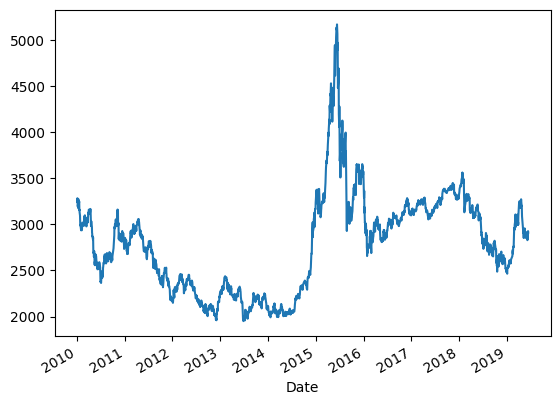

In [33]:
# plot the column of gap_high_low 如果不运行 inline 则打印不出来图片
trade_sh_2.Close.plot()

**Thanks a lot for your attention!**

# 4. Process data using pandas

## 4.1 Our tasks
预处理东方财富股吧中[光线传媒相关的评论](http://guba.eastmoney.com/list,300251.html)。股评数据保存在data文件夹,数据文件是300251.csv。主要工作包括：
* 读取数据
* 修改数据类型
* 删除不需要的列
* 删除光线传媒发布的文章 

数据清洗是数据分析第一步重要工作，特别是我们从网络抓取的数据，更是需要特别谨慎。**如果输入的是垃圾，那么得到的也是垃圾。** 作为数据分析人员，我们一定要敢于跳进数据中，干一些数据清洗的脏活累活。例如，CharGPT。

<img src="../img/garbage_in.jpg" align='left' height="350" width="350"/>
<img src="../img/cleaning.png" align='light' height="350" width="350"/>


## 4.2 Read data from csv

In [34]:
import pandas as pd
comments = pd.read_csv("300251.csv",encoding = "gbk")
comments.head()

,2019-03-25 16:13:22,光线传媒资讯,"http://guba.eastmoney.com/news,300251,811642819.html",\r\n 光线传媒:关于控股股东部分股份质押及质押延期购回的公告\r\n \r\n \r\n 公告日期：2019-03-25[查看历史公告]提示：本网不保证其真实性和客观性，一切有关该股的有效信息，以交易所的公告为准，敬请投资者注意风险。
0,2019-03-26 15:47:21,恭喜发财红利就来,"http://guba.eastmoney.com/news,300251,81192614...",\r\n 各位兄弟，再...
1,2019-03-26 16:18:41,老老老老老康,"http://guba.eastmoney.com/news,300251,81193282...",\r\n 继续加仓了，...
2,2019-03-26 17:04:14,说你点啥好呢,"http://guba.eastmoney.com/news,300251,81194240...",\r\n 跌破8块可以...
3,2019-03-26 17:30:25,资金解密,"http://guba.eastmoney.com/news,300251,81194742...",\r\n 光线传媒03...
4,2019-03-26 17:59:37,励琛研究,"http://guba.eastmoney.com/news,cfhpl,811952900...",\r\n 励琛研究丨互...


### 修改第一行，变成表头(列名)

In [35]:
columns = ['date','author','url','comment']
comments = pd.read_csv("300251.csv",
                       encoding = "gbk",
                      # header = None,
                      names = columns)
comments.head()

,date,author,url,comment
0,2019-03-25 16:13:22,光线传媒资讯,"http://guba.eastmoney.com/news,300251,81164281...",\r\n 光线传媒:关...
1,2019-03-26 15:47:21,恭喜发财红利就来,"http://guba.eastmoney.com/news,300251,81192614...",\r\n 各位兄弟，再...
2,2019-03-26 16:18:41,老老老老老康,"http://guba.eastmoney.com/news,300251,81193282...",\r\n 继续加仓了，...
3,2019-03-26 17:04:14,说你点啥好呢,"http://guba.eastmoney.com/news,300251,81194240...",\r\n 跌破8块可以...
4,2019-03-26 17:30:25,资金解密,"http://guba.eastmoney.com/news,300251,81194742...",\r\n 光线传媒03...


In [36]:
comments.shape

(129856, 4)

## 4.3 Data type conversion

这里我们主要使用函数[to_datetime](https://pandas.pydata.org/pandas-docs/version/0.15/generated/pandas.to_datetime.html)把字符串类型数据转化为日期，也可以使用[astype](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.astype.html)函数做其他类型转换。

In [37]:
# 查看数据类型,字符串类型的列会被当成object类型

comments.dtypes

date       object
author     object
url        object
comment    object
dtype: object

In [38]:
comments["date"] = pd.to_datetime(comments.date) # 转换成时间类型

In [39]:
comments.date[:2]

0   2019-03-25 16:13:22
1   2019-03-26 15:47:21
Name: date, dtype: datetime64[ns]

## 4.4 Drop column of url

In [40]:
# 还记得axis参数吗？

# axis = 0表示沿着每一列或行标签\索引值向下执行
# axis = 1表示沿着每一行或列标签\索引值横向执行对应

comments.drop("url",axis = 1).head()

,date,author,comment
0,2019-03-25 16:13:22,光线传媒资讯,\r\n 光线传媒:关...
1,2019-03-26 15:47:21,恭喜发财红利就来,\r\n 各位兄弟，再...
2,2019-03-26 16:18:41,老老老老老康,\r\n 继续加仓了，...
3,2019-03-26 17:04:14,说你点啥好呢,\r\n 跌破8块可以...
4,2019-03-26 17:30:25,资金解密,\r\n 光线传媒03...


In [41]:
# 请查看comments的列是否发生了变化

comments.head()

,date,author,url,comment
0,2019-03-25 16:13:22,光线传媒资讯,"http://guba.eastmoney.com/news,300251,81164281...",\r\n 光线传媒:关...
1,2019-03-26 15:47:21,恭喜发财红利就来,"http://guba.eastmoney.com/news,300251,81192614...",\r\n 各位兄弟，再...
2,2019-03-26 16:18:41,老老老老老康,"http://guba.eastmoney.com/news,300251,81193282...",\r\n 继续加仓了，...
3,2019-03-26 17:04:14,说你点啥好呢,"http://guba.eastmoney.com/news,300251,81194240...",\r\n 跌破8块可以...
4,2019-03-26 17:30:25,资金解密,"http://guba.eastmoney.com/news,300251,81194742...",\r\n 光线传媒03...


加入inplace参数：bool, default False.  If True, do operation inplace and return None.（就地删除）

In [42]:
# 加入inplace参数，就地删除

comments.drop("url",axis = 1,inplace=True)

In [43]:
# 请查看comments的列是否发生了变化

comments.columns

Index(['date', 'author', 'comment'], dtype='object')

In [44]:
comments.head()

,date,author,comment
0,2019-03-25 16:13:22,光线传媒资讯,\r\n 光线传媒:关...
1,2019-03-26 15:47:21,恭喜发财红利就来,\r\n 各位兄弟，再...
2,2019-03-26 16:18:41,老老老老老康,\r\n 继续加仓了，...
3,2019-03-26 17:04:14,说你点啥好呢,\r\n 跌破8块可以...
4,2019-03-26 17:30:25,资金解密,\r\n 光线传媒03...


## 4.5 Delete the comments posted by Enlight Media Co.,Ltd.

光线传媒公告和其他的财经评论的数据对于投资人决策也很重要，我们着重分析投资人评论对股价波动的影响，为了减少公司公告的影响，在此去掉了公司公告。如果要研究公司公告，需要特别分析公告的内容。

In [45]:
# 查看一下帖子作者的分布

comments.author.value_counts().head()

author
光线传媒资讯         3782
可乐与白开水5783     2020
股神9818          519
hhl10160012     511
锅包肉1979         477
Name: count, dtype: int64

In [46]:
# 查询光线传媒自己发布的公告，即author = "光线传媒资讯"

#b = (comments["author"]=="光线传媒资讯")
b = (comments["author"]!="光线传媒资讯")
comments[b]

,date,author,comment
1,2019-03-26 15:47:21,恭喜发财红利就来,\r\n 各位兄弟，再...
2,2019-03-26 16:18:41,老老老老老康,\r\n 继续加仓了，...
3,2019-03-26 17:04:14,说你点啥好呢,\r\n 跌破8块可以...
4,2019-03-26 17:30:25,资金解密,\r\n 光线传媒03...
5,2019-03-26 17:59:37,励琛研究,\r\n 励琛研究丨互...
...,...,...,...
129851,2011-08-04 20:15:14,NaN,\r\n 178\r\...
129852,2011-07-29 08:04:39,NaN,\r\n 破发无悬念，...
129853,2011-07-25 12:29:19,NaN,\r\n 破发从这个开...
129854,2011-07-30 19:57:17,NaN,\r\n 无德，无道，...


In [47]:
# 一个光线传媒公告实例

comments.comment[33]

'\r\n                                    光线传媒:第四届董事会第六次会议决议公告\r\n                                            \r\n                                    \r\n                                        公告日期：2019-03-28[查看历史公告]提示：本网不保证其真实性和客观性，一切有关该股的有效信息，以交易所的公告为准，敬请投资者注意风险。'

In [48]:
# 删除光线传媒发布的公告

print(len(comments))
comments = comments[comments["author"]!="光线传媒资讯"] # 重新赋值
len(comments)

129856


126074

In [49]:
# 删除资金解密、聚焦沪深港发布的文章

comments = comments[comments["author"]!="资金解密"]
comments = comments[comments["author"]!="聚焦沪深港"]
comments = comments[comments["author"]!="财经评论"]
len(comments)

124946

**Thanks a lot for your attention!**

# 5. Process text data using pandas

## 5.1 Processing text in Series（针对字符串，pd中有一些专门的工具）

**通过序列的str属性及其相关函数，我们可以对序列的文本元素做处理，类似传统字符串函数，例如lower(), upper(),len(),strip(),replace(),split().**

In [50]:
imdb = pd.read_table(
        'imdb_top_10000.txt', 
        names=['imdbID', 'title', 'year', 'score', 
               'votes', 'runtime', 'genres']
        )

In [51]:
imdb.head()

#imdb.dtypes

,imdbID,title,year,score,votes,runtime,genres
0,tt0111161,The Shawshank Redemption (1994),1994,9.2,619479,142 mins.,Crime|Drama
1,tt0110912,Pulp Fiction (1994),1994,9.0,490065,154 mins.,Crime|Thriller
2,tt0137523,Fight Club (1999),1999,8.8,458173,139 mins.,Drama|Mystery|Thriller
3,tt0133093,The Matrix (1999),1999,8.7,448114,136 mins.,Action|Adventure|Sci-Fi
4,tt1375666,Inception (2010),2010,8.9,385149,148 mins.,Action|Adventure|Sci-Fi|Thriller


In [52]:
imdb.genres.str.split("|").head() 

0                           [Crime, Drama]
1                        [Crime, Thriller]
2               [Drama, Mystery, Thriller]
3              [Action, Adventure, Sci-Fi]
4    [Action, Adventure, Sci-Fi, Thriller]
Name: genres, dtype: object

In [53]:
# We can also get dumb variables for movie genres

genres = imdb.genres.str.get_dummies(sep="|") ## 哑变量生成方法，把某一列拆开
genres.head()

,Action,Adult,Adventure,Animation,Biography,Comedy,Crime,Drama,Family,Fantasy,...,Musical,Mystery,News,Reality-TV,Romance,Sci-Fi,Sport,Thriller,War,Western
0,0,0,0,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,1,0,0
3,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0


In [54]:
# The two dataframes can be joined according to the direction of the column

new_imdb = pd.concat([imdb,genres],axis=1)
new_imdb.head()

,imdbID,title,year,score,votes,runtime,genres,Action,Adult,Adventure,...,Musical,Mystery,News,Reality-TV,Romance,Sci-Fi,Sport,Thriller,War,Western
0,tt0111161,The Shawshank Redemption (1994),1994,9.2,619479,142 mins.,Crime|Drama,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,tt0110912,Pulp Fiction (1994),1994,9.0,490065,154 mins.,Crime|Thriller,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,tt0137523,Fight Club (1999),1999,8.8,458173,139 mins.,Drama|Mystery|Thriller,0,0,0,...,0,1,0,0,0,0,0,1,0,0
3,tt0133093,The Matrix (1999),1999,8.7,448114,136 mins.,Action|Adventure|Sci-Fi,1,0,1,...,0,0,0,0,0,1,0,0,0,0
4,tt1375666,Inception (2010),2010,8.9,385149,148 mins.,Action|Adventure|Sci-Fi|Thriller,1,0,1,...,0,0,0,0,0,1,0,1,0,0


In [55]:
imdb.genres.str.get_dummies(sep="|")

,Action,Adult,Adventure,Animation,Biography,Comedy,Crime,Drama,Family,Fantasy,...,Musical,Mystery,News,Reality-TV,Romance,Sci-Fi,Sport,Thriller,War,Western
0,0,0,0,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,1,0,0
3,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
9996,0,0,0,0,0,1,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
9997,0,0,0,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,1,0,0
9998,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0


## 5.2 Clean the text of comments on stocks

In [56]:
# check one comment 前后空格与换行

comments["comment"][8]

'\r\n                                    贝壳D轮。光线之前投了\r\n                                \r\n                                    \r\n                                        贝壳D轮。光线之前投了\r\n\r\n                                                '

In [57]:
# Remove the Spaces and assign to clean_comments

clean_comments = comments.comment.str.replace(" ","")
clean_comments

1                  \r\n各位兄弟，再见！\r\n\r\n\r\n各位兄弟，再见！\r\n\r\n
2         \r\n继续加仓了，就当存银行定期吧[摊手][摊手][摊手]\r\n\r\n\r\n继续加仓...
3                \r\n跌破8块可以抄底了\r\n\r\n\r\n跌破8块可以抄底了\r\n\r\n
5         \r\n励琛研究丨互联网巨头亏损状态\r\n\r\n\r\n2018年，中国第二代互联网亏损...
6         \r\n这厮已经回到年初大盘两千五百点左右的价位了\r\n\r\n\r\n这厮已经回到年初大...
                                ...                        
129851    \r\n178\r\n\r\n\r\n看光线传媒（300251）最新动态，老板太有实力了·\...
129852    \r\n破发无悬念，看看目前新股的上市情况，你懂得。\r\n\r\n\r\n呵呵，就涨10％...
129853                  \r\n破发从这个开始.十年打新经验\r\n\r\n\r\n钱多人不傻
129854    \r\n无德，无道，无利可图就是61倍发行的光线。破发太简单！！\r\n\r\n\r\n缺老...
129855    \r\n买这个股的死路一条\r\n\r\n\r\n我没有看见几个基金买的股票涨的好的。这个可...
Name: comment, Length: 124946, dtype: object

In [58]:
# remove returns
clean_comments = clean_comments.str.replace('\r\n', '')
clean_comments = clean_comments.str.replace('\r', '')

comments["comment"] = clean_comments

In [59]:
# get the first five rows
comments.head()

,date,author,comment
1,2019-03-26 15:47:21,恭喜发财红利就来,各位兄弟，再见！各位兄弟，再见！
2,2019-03-26 16:18:41,老老老老老康,继续加仓了，就当存银行定期吧[摊手][摊手][摊手]继续加仓了，就当存银行定期吧
3,2019-03-26 17:04:14,说你点啥好呢,跌破8块可以抄底了跌破8块可以抄底了
5,2019-03-26 17:59:37,励琛研究,励琛研究丨互联网巨头亏损状态2018年，中国第二代互联网亏损，已经成为这届互联网上市公司躲不...
6,2019-03-26 19:23:21,zxg515,这厮已经回到年初大盘两千五百点左右的价位了这厮已经回到年初大盘两千五百点左右的价位了


In [60]:
comments["comment"][8]

'贝壳D轮。光线之前投了贝壳D轮。光线之前投了'

**Thanks a lot for your attention!**